In [8]:
# %matplotlib widget
import threading
import time
import matplotlib.pyplot as plt
import nest_asyncio
import numpy as np
nest_asyncio.apply()  # required in notebooks

from phyling.ble import NanoPhyling, MiniPhyling

## Device setup

Choose one device below.

In [2]:
device = NanoPhyling(ble_name="NanoPhyling_38")

## on_data — callback fired on every incoming packet

`device.on_data(callback)` registers a function called with a small DataFrame after each BLE
notification. The DataFrame has columns `T` (seconds from recording start) and all sensor
columns with calibration already applied.

Because `device.run()` is blocking it runs in a background thread while the callback
executes on the asyncio event loop.

In [10]:
# Simple example: print the latest acc_z value as data arrives
def print_latest(df):
    row = df.iloc[-1]
    print(f"T={row['T']:.2f}s  acc x={row['acc_x']:.4f} acc y={row['acc_y']:.4f} acc z={row['acc_z']:.4f}")
    print(f"   gyro x={row['gyro_x']:.4f} gyro y={row['gyro_y']:.4f} gyro z={row['gyro_z']:.4f}")
    mag_acc = np.sqrt(row["acc_x"] ** 2 + row["acc_y"] ** 2 + row["acc_z"] ** 2)
    mag_gyro = np.sqrt(row["gyro_x"] ** 2 + row["gyro_y"] ** 2 + row["gyro_z"] ** 2)
    print(f" magnitude acc={mag_acc:.4f} magnitude gyro={mag_gyro:.4f}")

device.on_data(print_latest)

# Run for 10 seconds in a background thread
t = threading.Thread(target=device.run, kwargs={"duration": 10}, daemon=True)
t.start()
t.join()

[NanoPhyling_38] Device NanoPhyling_38 Connected
[NanoPhyling_38] Recording started
T=0.00s  acc x=0.2106 acc y=-9.7230 acc z=-0.6415
   gyro x=-0.1400 gyro y=-4.0600 gyro z=-1.0500
 magnitude acc=9.7464 magnitude gyro=4.1959
T=0.08s  acc x=0.2250 acc y=-9.6799 acc z=-0.6463
   gyro x=-0.3500 gyro y=-3.9900 gyro z=-1.0500
 magnitude acc=9.7040 magnitude gyro=4.1407
[NanoPhyling_38] Recording stopped (30 samples)


## on_data — live plot

The callback appends each batch to rolling buffers and updates a matplotlib figure in real time.

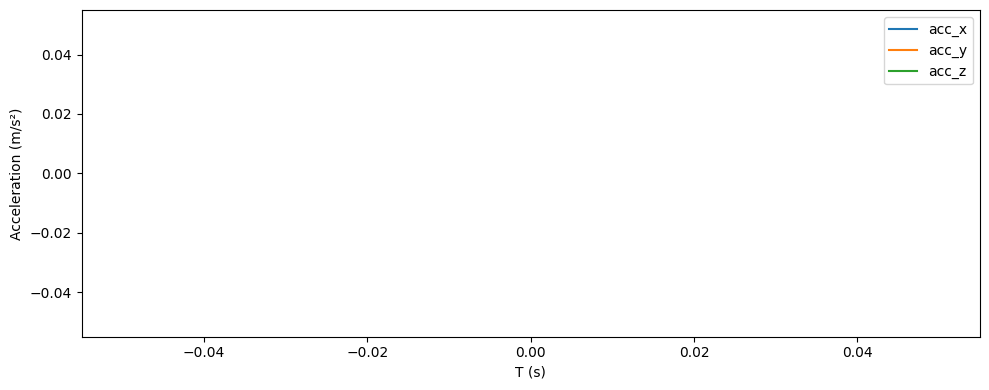

In [11]:
WINDOW = 200  # number of samples shown in the rolling window

buf_T   = []
buf_acc_x = []
buf_acc_y = []
buf_acc_z = []

fig, ax = plt.subplots(figsize=(10, 4))
line_x, = ax.plot([], [], label="acc_x")
line_y, = ax.plot([], [], label="acc_y")
line_z, = ax.plot([], [], label="acc_z")
ax.set_xlabel("T (s)")
ax.set_ylabel("Acceleration (m/s²)")
ax.legend()
plt.tight_layout()

def update_plot(df):
    buf_T.extend(df["T"].tolist())
    buf_acc_x.extend(df["acc_x"].tolist())
    buf_acc_y.extend(df["acc_y"].tolist())
    buf_acc_z.extend(df["acc_z"].tolist())

    t_win   = buf_T[-WINDOW:]
    line_x.set_data(t_win, buf_acc_x[-WINDOW:])
    line_y.set_data(t_win, buf_acc_y[-WINDOW:])
    line_z.set_data(t_win, buf_acc_z[-WINDOW:])
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

device.on_data(update_plot)

t = threading.Thread(target=device.run, kwargs={"duration": 30}, daemon=True)
t.start()

In [12]:
# Stop early if needed
device.disconnect = True

## get_latest — polling-based access

`device.get_latest(n)` returns the last `n` rows at any moment while recording is running.
Useful when you want to pull data on your own schedule rather than react to each packet.

In [ ]:
device.on_data(None)  # clear any previous callback

t = threading.Thread(target=device.run, kwargs={"duration": 30}, daemon=True)
t.start()

# Poll every 100 ms and print a live summary
while t.is_alive():
    df = device.get_latest(50)  # last 50 samples
    if df is not None:
        print(
            f"\rT={df['T'].iloc[-1]:.2f}s  "
            f"acc_z mean={df['acc_z'].mean():.4f}  "
            f"gyro_z mean={df['gyro_z'].mean():.4f}",
            end="",
        )
    time.sleep(0.1)

[NanoPhyling_38] Device NanoPhyling_38 Connected
[NanoPhyling_38] Device NanoPhyling_38 Connected
[NanoPhyling_38] Recording started
T=0.00s  acc_z mean=-0.6415  gyro_z mean=-1.0733[NanoPhyling_38] Recording started
T=0.87s  acc_z mean=-0.6281  gyro_z mean=-1.0682

KeyboardInterrupt: 

[NanoPhyling_38] Recording stopped (14700 samples)
[NanoPhyling_38] Unexpected disconnect. Reconnecting in 1s...
[NanoPhyling_38] Recording stopped (14700 samples)
[NanoPhyling_38] Unexpected disconnect. Reconnecting in 1s...
[NanoPhyling_38] Device NanoPhyling_38 Connected
[NanoPhyling_38] Connection error: (<BleakGATTProtocolErrorCode.UNLIKELY_ERROR: 14>, 'GATT Protocol Error: Unlikely Error'). Reconnecting in 1s...


## Retrieve full recording after stopping

`get_df()` still works as before — returns the complete calibrated DataFrame with `T`, `time`,
and `fs` columns after `_apply_sync()` has run.

In [ ]:
df = device.get_df()
df.head()